<a href="https://colab.research.google.com/github/sathkumara-smna/258739K/blob/main/Site_Power_Prection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

site_db_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power%20from%20Sey.xlsx"
site_db = pd.read_excel(site_db_url)
site_db.head(2)

,Site_ID,trigger_ID,date,datetime,site_power
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512


In [91]:
power_2g3g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power_2g3g.xlsx"
power_2g3g = pd.read_excel(power_2g3g_url)
power_2g3g.head(2)

,Site_ID,rru_count_2g,rru_2g_bp,power_2g,rru_count_3g,rru_3g_bp,power_3g,total_2g_3g_power
0,101,3,150,450,7,200,1400,1850
1,102,2,150,300,4,200,800,1100


In [92]:
power_4g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power_lte.xlsx"
power_4g = pd.read_excel(power_4g_url)
power_4g.head(2)

,Site_ID,trigger_ID,date,datetime,site_power
0,101,1,2026-03-01,2026-03-01 00:00,2470.12
1,101,2,2026-03-01,2026-03-01 00:15,2473.34


In [93]:
power_5g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power_5g.xlsx"
power_5g = pd.read_excel(power_5g_url)
power_5g.head(2)

,Site_ID,trigger_ID,date,datetime,site_5g_power
0,101,1,2026-03-01,2026-03-01 00:00,1752.97
1,101,2,2026-03-01,2026-03-01 00:15,1762.42


In [94]:
# Add power_2g3g column to site_db using Site_ID matching

site_db['power_2g3g'] = (

    site_db['Site_ID'].map(power_2g3g.set_index('Site_ID')['total_2g_3g_power'])
)
# Show first rows
site_db.head()

,Site_ID,trigger_ID,date,datetime,site_power,power_2g3g
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,1850
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,1850
2,101,3,2026-03-01,2026-03-01 00:30,5861.2925,1850
3,101,4,2026-03-01,2026-03-01 00:45,6290.3504,1850
4,101,5,2026-03-01,2026-03-01 01:00,6282.3500,1850


In [95]:
# Add 4G power column to site_db
# Matching using Site_ID, trigger_ID, and date

site_db = site_db.merge(

    power_4g[
        ['Site_ID', 'trigger_ID', 'date', 'site_power']
    ].rename(columns={'site_power': 'power_4g'}),

    on=['Site_ID', 'trigger_ID', 'date'],how='left')

# Show first rows
site_db.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,power_2g3g,power_4g
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,1850,2470.12
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,1850,2473.34


In [96]:
# Add 5G power column to site_db
# Matching using Site_ID, trigger_ID, and date

site_db = site_db.merge(

    power_5g[
        ['Site_ID', 'trigger_ID', 'date', 'site_5g_power']
    ].rename(columns={'site_5g_power': 'power_5g'}
    ),
    on=['Site_ID', 'trigger_ID', 'date'],
    how='left'

)
# Show first rows
site_db.head()

,Site_ID,trigger_ID,date,datetime,site_power,power_2g3g,power_4g,power_5g
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,1850,2470.12,1752.97
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,1850,2473.34,1762.42
2,101,3,2026-03-01,2026-03-01 00:30,5861.2925,1850,2474.87,1772.28
3,101,4,2026-03-01,2026-03-01 00:45,6290.3504,1850,2476.09,1779.59
4,101,5,2026-03-01,2026-03-01 01:00,6282.3500,1850,2478.52,1788.48


In [97]:
# Replace empty values with 0

site_db['power_2g3g'] = (site_db['power_2g3g'].fillna(0))
site_db['power_4g'] = (site_db['power_4g'].fillna(0))
site_db['power_5g'] = (site_db['power_5g'].fillna(0))

# Recalculate total predicted power
site_db['site_total_predicted_power'] = (site_db['power_2g3g']+site_db['power_4g']+site_db['power_5g'])
# Show first rows
site_db.head()

,Site_ID,trigger_ID,date,datetime,site_power,power_2g3g,power_4g,power_5g,site_total_predicted_power
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,1850,2470.12,1752.97,6073.09
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,1850,2473.34,1762.42,6085.76
2,101,3,2026-03-01,2026-03-01 00:30,5861.2925,1850,2474.87,1772.28,6097.15
3,101,4,2026-03-01,2026-03-01 00:45,6290.3504,1850,2476.09,1779.59,6105.68
4,101,5,2026-03-01,2026-03-01 01:00,6282.3500,1850,2478.52,1788.48,6117.00


In [98]:
site_db.to_excel('Total_Power_Prediction_Eng_Rule.xlsx',index=False)

In [102]:
# ============================================================
# ERROR PERCENTAGE
# ============================================================

site_db['error_percentage'] = (
    np.abs(site_db['site_power'] - site_db['site_total_predicted_power'])/site_db['site_power']) * 100

# ============================================================
# MAXIMUM AND MINIMUM ERROR %
# ============================================================

max_error = site_db['error_percentage'].max()
min_error = site_db['error_percentage'].min()

# ============================================================
# PRINT RESULTS
# ============================================================

print("================================")
print("ENGINEERING RULE PERFORMANCE")
print("================================")

print(f"MAE               : {round(mae, 2)}")
print(f"RMSE              : {round(rmse, 2)}")
print(f"MAPE              : {round(mape, 2)} %")
print(f"R2                : {round(r2, 4)}")

print("--------------------------------")

print(f"Maximum Error %   : {round(max_error, 2)} %")
print(f"Minimum Error %   : {round(min_error, 2)} %")

ENGINEERING RULE PERFORMANCE
MAE               : 175.14
RMSE              : 251.0
MAPE              : 4.15 %
R2                : 0.9851
--------------------------------
Maximum Error %   : 13.04 %
Minimum Error %   : 0.0 %


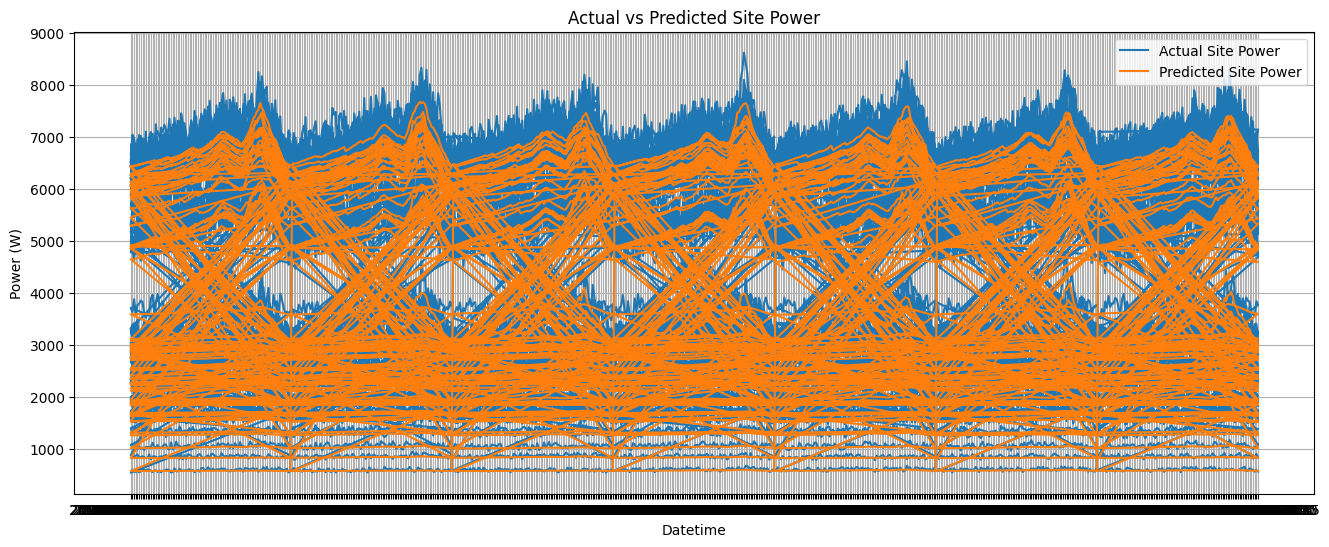

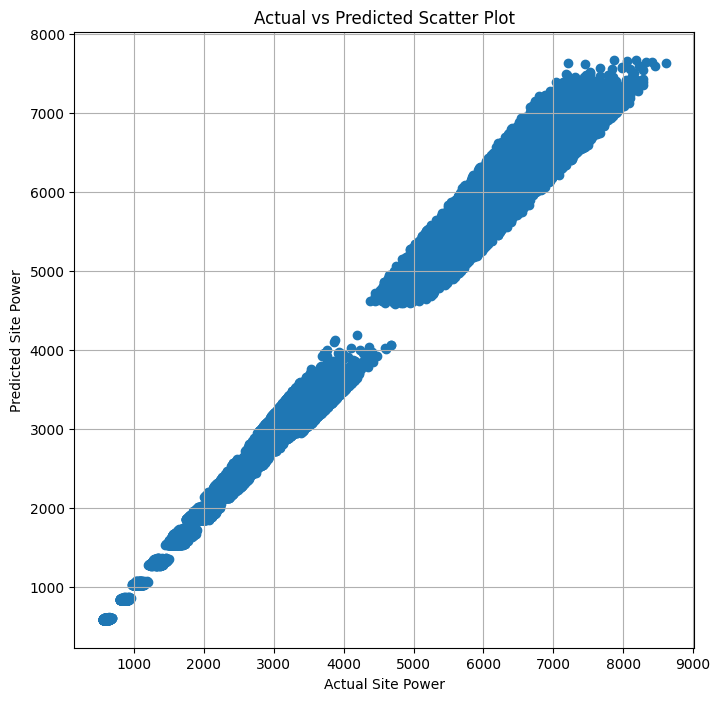

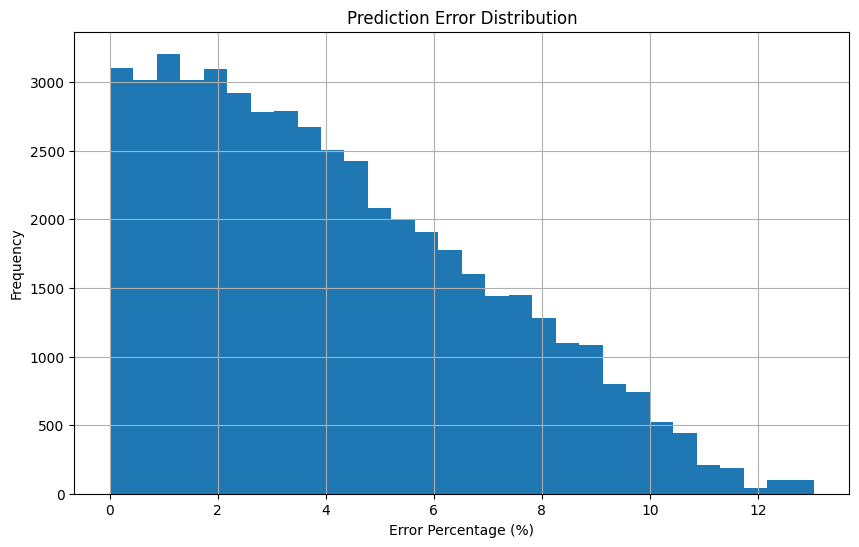

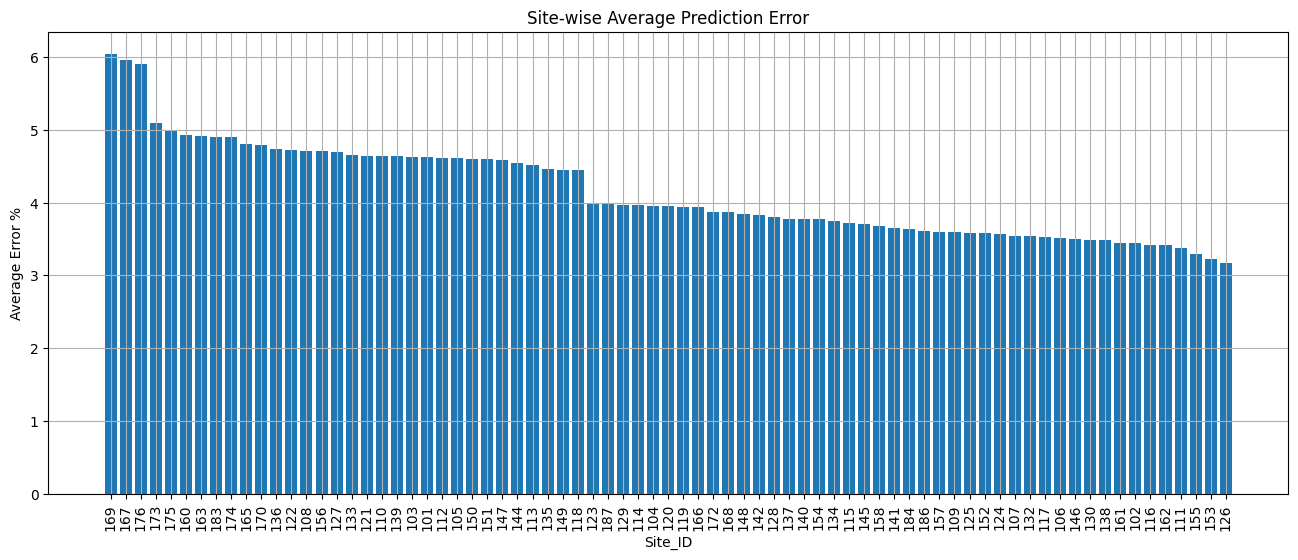

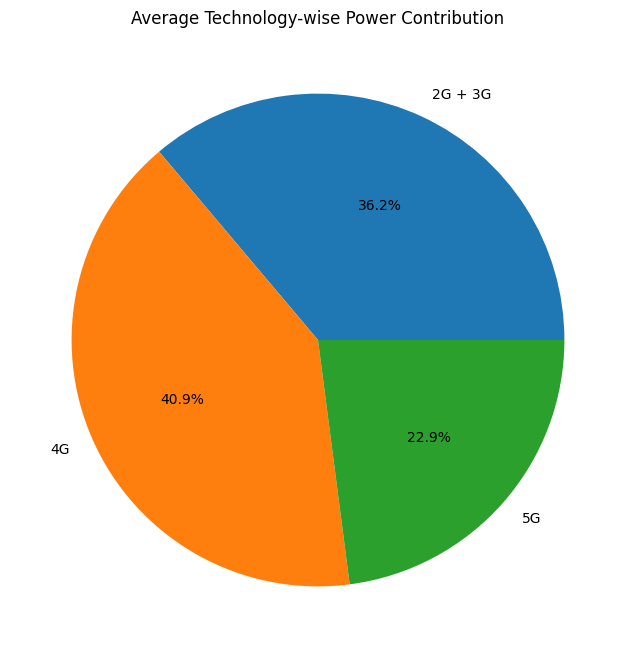

In [104]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# ACTUAL VS PREDICTED POWER GRAPH
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    site_db['datetime'],
    site_db['site_power'],
    label='Actual Site Power'
)

plt.plot(
    site_db['datetime'],
    site_db['site_total_predicted_power'],
    label='Predicted Site Power'
)

plt.xlabel('Datetime')
plt.ylabel('Power (W)')
plt.title('Actual vs Predicted Site Power')
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# SCATTER PLOT
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    site_db['site_power'],
    site_db['site_total_predicted_power']
)

plt.xlabel('Actual Site Power')
plt.ylabel('Predicted Site Power')
plt.title('Actual vs Predicted Scatter Plot')
plt.grid(True)
plt.show()

# ============================================================
# ERROR PERCENTAGE HISTOGRAM
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    site_db['error_percentage'],
    bins=30
)

plt.xlabel('Error Percentage (%)')
plt.ylabel('Frequency')
plt.title('Prediction Error Distribution')
plt.grid(True)
plt.show()

# ============================================================
# SITE-WISE AVERAGE ERROR
# ============================================================

site_error = (

    site_db.groupby('Site_ID')['error_percentage']
    .mean()
    .reset_index()

)

site_error = site_error.sort_values(
    by='error_percentage',
    ascending=False
)

plt.figure(figsize=(16,6))

plt.bar(
    site_error['Site_ID'].astype(str),
    site_error['error_percentage']
)

plt.xticks(rotation=90)
plt.xlabel('Site_ID')
plt.ylabel('Average Error %')
plt.title('Site-wise Average Prediction Error')
plt.grid(True)
plt.show()

# ============================================================
# TECHNOLOGY CONTRIBUTION PIE CHART
# ============================================================

avg_2g3g = site_db['power_2g3g'].mean()
avg_4g = site_db['power_4g'].mean()
avg_5g = site_db['power_5g'].mean()
plt.figure(figsize=(8,8))
plt.pie(

    [
        avg_2g3g,
        avg_4g,
        avg_5g
    ],

    labels=[
        '2G + 3G',
        '4G',
        '5G'
    ],

    autopct='%1.1f%%'

)

plt.title('Average Technology-wise Power Contribution')

plt.show()